### Import Libary

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy import stats
from scipy.stats import mannwhitneyu


### Read csv files

In [2]:
df_divar = pd.read_csv('Divar.csv')
df_city = pd.read_csv('iran_city_classification.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_14464\1209214127.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_divar = pd.read_csv('Divar.csv')


### EDA

In [3]:
df_divar.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_city.head()

,نام شهر,دسته‌بندی
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,mashhad,کلان‌شهر
3,ahvaz,کلان‌شهر
4,kermanshah,کلان‌شهر


In [5]:
df_divar.shape

(1000000, 61)

In [6]:
df_city.shape

(240, 2)

In [7]:
df_divar.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000000.0,4.999995e+05,2.886753e+05,0.000000,2.499998e+05,4.999995e+05,7.499992e+05,9.999990e+05
rent_value,351322.0,4.102299e+10,3.807534e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
credit_value,352095.0,4.872084e+10,4.341346e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformable_credit,352085.0,4.872222e+10,4.341407e+12,0.000000,1.000000e+08,2.500000e+08,5.000000e+08,1.000000e+15
transformed_credit,72409.0,8.557025e+09,2.064576e+12,0.000000,2.000000e+08,4.000000e+08,8.500000e+08,5.555556e+14
transformable_rent,351248.0,4.103164e+10,3.807935e+12,0.000000,1.111110e+05,5.000000e+06,1.200000e+07,1.000000e+15
transformed_rent,72409.0,1.619934e+07,5.217890e+07,0.000000,1.000000e+06,6.000000e+06,1.500000e+07,3.000000e+09
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07


In [8]:
df_divar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 61 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   Unnamed: 0                  1000000 non-null  int64  
 1   cat2_slug                   1000000 non-null  str    
 2   cat3_slug                   999999 non-null   str    
 3   city_slug                   999998 non-null   str    
 4   neighborhood_slug           437139 non-null   str    
 5   created_at_month            1000000 non-null  str    
 6   user_type                   288882 non-null   str    
 7   description                 1000000 non-null  str    
 8   title                       999946 non-null   str    
 9   rent_mode                   352994 non-null   str    
 10  rent_value                  351322 non-null   float64
 11  rent_to_single              19 non-null       object 
 12  rent_type                   103961 non-null   str    
 13  price_mod

In [9]:
df_divar.isnull().sum()

Unnamed: 0                         0
cat2_slug                          0
cat3_slug                          1
city_slug                          2
neighborhood_slug             562861
                               ...  
rent_price_on_special_days    989537
rent_price_at_weekends        986449
location_latitude             344392
location_longitude            344392
location_radius               660301
Length: 61, dtype: int64

In [10]:
df_divar['cat2_slug'].value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [11]:
df_divar['cat2_slug'].value_counts(normalize=True) * 100

cat2_slug
residential-sell        55.8708
residential-rent        27.6558
commercial-rent          7.6567
commercial-sell          3.8861
temporary-rent           2.9903
real-estate-services     1.9403
Name: proportion, dtype: float64

In [12]:
df_divar['cat3_slug'].value_counts()

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64

In [13]:
df_divar['cat3_slug'].value_counts(normalize=True) * 100

cat3_slug
apartment-sell                        30.338530
apartment-rent                        21.188021
plot-old                              13.357013
house-villa-sell                      12.175312
house-villa-rent                       6.467806
shop-rent                              4.599305
shop-sell                              2.185502
office-rent                            2.141802
suite-apartment                        1.646502
presell                                1.578102
villa                                  1.289901
industry-agriculture-business-sell     1.185101
industry-agriculture-business-rent     0.915501
office-sell                            0.515501
partnership                            0.362200
workspace                              0.053900
Name: proportion, dtype: float64

In [14]:
df_divar['cat3_slug'].nunique()

16

### آمار توصيفی 

<div dir="rtl" align="right">
توزیع آگهی‌های موجود در دسته‌های مختلف را برای دسته‌بندی سطح دو و سطح سه رسم کنید.
</div>

<div dir="rtl" align="right">
سطح دو
</div>

In [54]:
### in ghesmat baraye ine ke soton nemodar ha farsi beshe age fek mikoni niyaz nist hazfesh kon

In [15]:
cat2_translate = {
    'residential-sell': 'فروش مسکونی',
    'residential-rent': 'اجاره مسکونی',
    'commercial-rent': 'اجاره تجاری',
    'commercial-sell': 'فروش تجاری',
    'temporary-rent': 'اجاره موقت',
    'real-estate-services': 'خدمات املاک'
}

labels = df_divar['cat2_slug'].value_counts().index.map(cat2_translate)

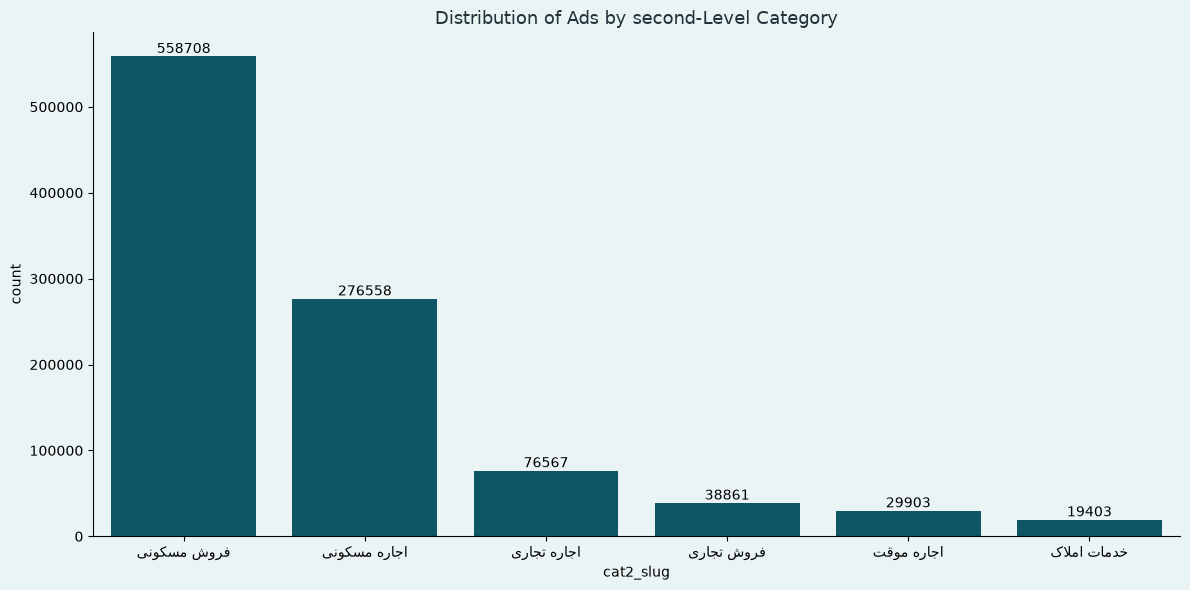

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(data=df_divar, x='cat2_slug', legend=False, ax=ax, color='#005f73',
              order=df_divar['cat2_slug'].value_counts().index)   # order= sorts bars by frequency

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

ax.set_title('Distribution of Ads by second-Level Category', fontsize= 13, color='#22333b')
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.set_facecolor(color='#EAF4f4')
fig.set_facecolor('#EAF4f4')

# age cell bala ro hazf kardi (farsi saz) in ye khate pain ham hazf kon
plt.xticks(ticks=range(len(labels)), labels=labels)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

بیشترین تعداد آگهی (55.8%) مربوط به دسته residential-sell (فروش مسکونی) است که اختلاف زیادی با سایر دسته‌ها دارد. بعد از آن residential-rent (اجاره مسکونی) بیشترین سهم را دارد (با 27.6%). این موضوع نشان می‌دهد بخش بزرگی از داده‌های موجود مربوط به معاملات مسکونی است، در حالی که دسته‌های تجاری و خدماتی تعداد کمتری آگهی دارند.  

</div>

<div dir="rtl" align="right">
 سطح سه
</div>

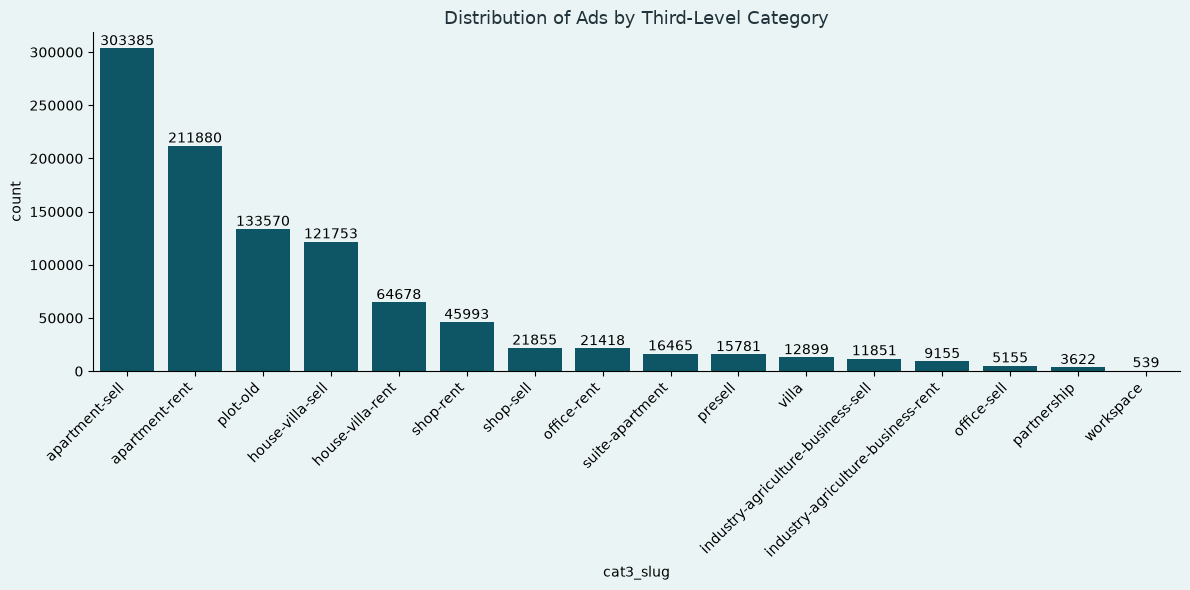

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.countplot(data=df_divar, x='cat3_slug', legend=False, ax=ax, color='#005f73',
              order=df_divar['cat3_slug'].value_counts().index)   # order= sorts bars by frequency

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

ax.set_title('Distribution of Ads by Third-Level Category', fontsize= 13, color='#22333b')
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.set_facecolor(color='#EAF4f4')
fig.set_facecolor('#EAF4f4')

plt.xticks(rotation=45, ha='right') #ticks=range(len(labels)), labels=labels
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

بيشترين آگهی ها در دسته بندی سطح 3 مربوط به فروش آپارتمان با 33.3% ، اجاره آپارتمان با 21.18% است که اين دو دسته به تنهایی بخش قابل توجه ای از اگهی ها را به خود اختصاص دادن .


</div>

<div dir="rtl" align="right">

هیستوگرام سال ساخت را رسم کنید.

</div>

### EDA

In [18]:
df_divar["construction_year"]

0                 NaN
1                ۱۳۸۴
2                ۱۴۰۱
3                ۱۴۰۰
4                ۱۴۰۳
             ...     
999995           ۱۴۰۳
999996           ۱۴۰۳
999997    قبل از ۱۳۷۰
999998            NaN
999999           ۱۳۸۲
Name: construction_year, Length: 1000000, dtype: str

In [19]:
df_divar['construction_year'].isnull().sum()

np.int64(184172)

In [20]:
df_divar['construction_year'].value_counts()

construction_year
۱۴۰۳           116260
۱۳۹۰            59139
۱۴۰۲            58424
۱۴۰۰            53674
۱۳۹۵            53029
۱۳۹۸            38207
۱۳۹۷            36326
۱۳۹۶            35487
۱۴۰۱            35328
۱۳۸۵            34065
۱۳۹۹            29594
۱۳۹۳            29094
۱۳۹۲            26130
۱۳۹۴            26110
۱۳۸۸            24268
۱۳۸۰            23480
قبل از ۱۳۷۰     20637
۱۳۸۹            16755
۱۳۹۱            16316
۱۳۸۷            14136
۱۳۸۶            13468
۱۳۸۳             9894
۱۳۸۴             8494
۱۳۷۵             7247
۱۳۸۲             6965
۱۳۷۱             5531
۱۳۸۱             3590
۱۳۷۸             3025
۱۳۷۹             2415
۱۳۷۷             2117
۱۳۷۲             1914
۱۳۷۳             1827
۱۳۷۶             1593
۱۳۷۴             1289
Name: count, dtype: int64

In [21]:
df_divar['construction_year'].nunique()

34

In [56]:
### tabdil soton saale sakht az str be numerical

In [22]:
def convert_persian_year(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    if value == 'قبل از ۱۳۷۰':
        return 1369

    persian_to_english = str.maketrans(
        '۰۱۲۳۴۵۶۷۸۹',
        '0123456789'
    )
    
    value = value.translate(persian_to_english)
    return int(value)

In [23]:
df_divar['construction_year_numeric'] = df_divar['construction_year'].apply(convert_persian_year)
df_divar['construction_year_numeric']

0            NaN
1         1384.0
2         1401.0
3         1400.0
4         1403.0
           ...  
999995    1403.0
999996    1403.0
999997    1369.0
999998       NaN
999999    1382.0
Name: construction_year_numeric, Length: 1000000, dtype: float64

In [24]:
df_divar['construction_year_numeric'].describe()

count    815828.000000
mean       1393.777172
std           8.349677
min        1369.000000
25%        1390.000000
50%        1395.000000
75%        1401.000000
max        1403.000000
Name: construction_year_numeric, dtype: float64

<div dir="rtl" align="right">

رسم نمودار بدون هندل کردن داده های​ نال يا ستون های هدف

</div>

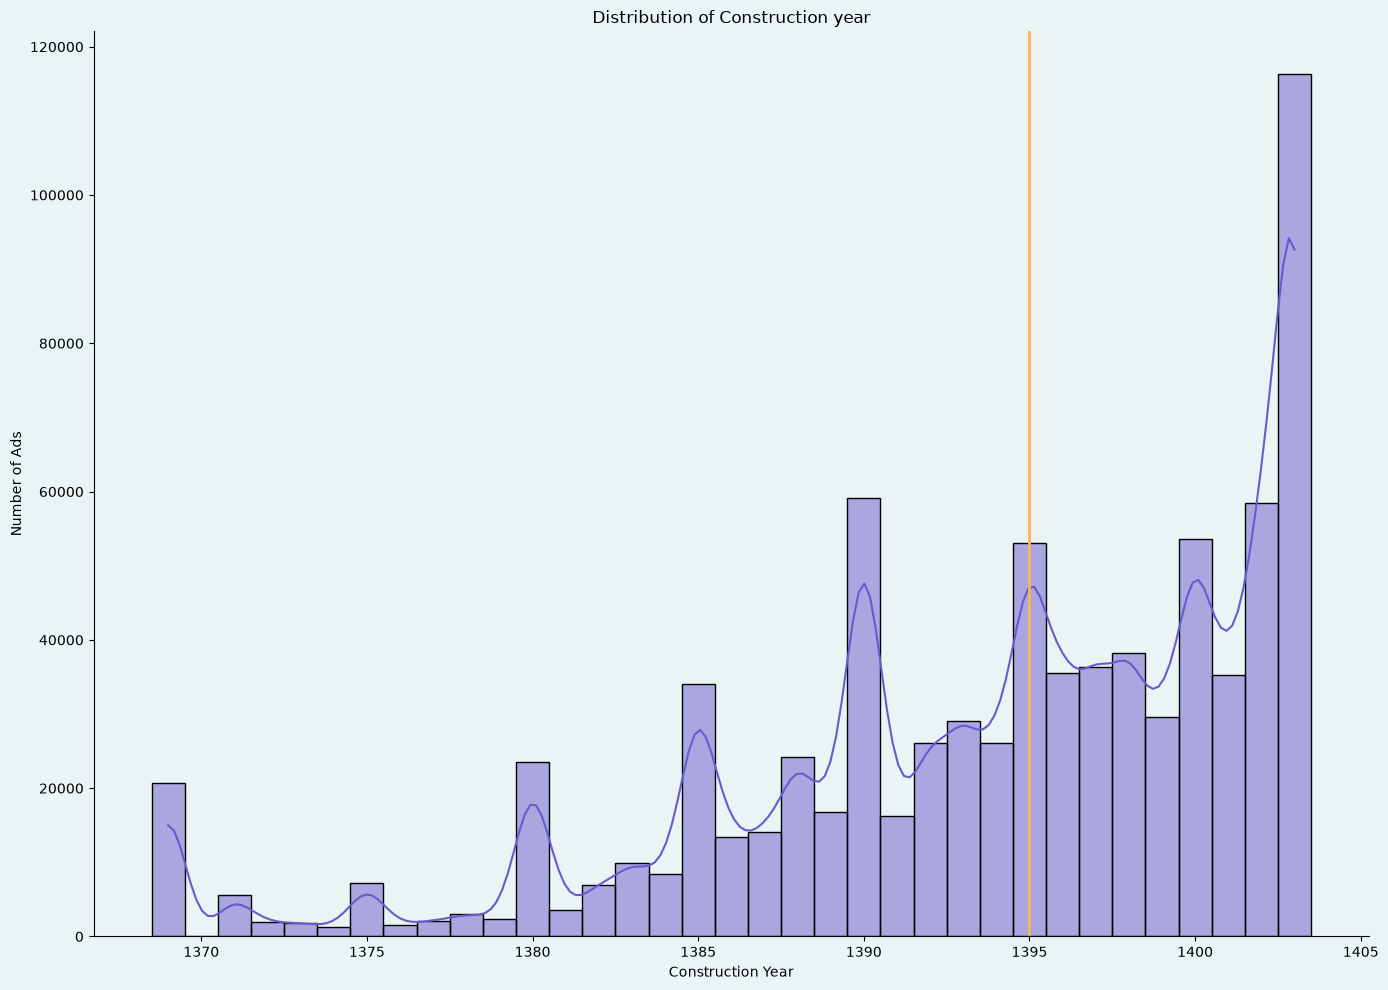

In [25]:
bins = np.arange(1368.5, 1404.5, 1)

fig1, ax1 = plt.subplots(figsize=(14, 10))

sns.histplot(data=df_divar, x='construction_year_numeric', bins=bins, kde=True, ax=ax1, color='slateblue')

ax1.axvline(df_divar['construction_year_numeric'].median(), color='#ffb454', linewidth=2)

ax1.set_title('Distribution of Construction year')
ax1.set_xlabel('Construction Year')
ax1.set_ylabel('Number of Ads')
ax1.spines.right.set_visible(False)
ax1.spines.top.set_visible(False)
ax1.set_facecolor(color='#EAF4f4')
fig1.set_facecolor('#EAF4f4')

plt.tight_layout()
plt.show()

In [ ]:
### in celll pain baraye tabdil tarikh bod baraye handel kardan missing value haye saale sakht az roye title va descripton ba regex
### ke kolan tasmim bar in shod ke bejaye handel kardan missing ha az on 2 soton bejash jamye hadafm ro moshakhas konam

In [26]:
import jdatetime

def gregorian_to_jalali_year(date):

    if pd.isna(date):
        return np.nan

    date = pd.to_datetime(date)
    jalali_date = jdatetime.date.fromgregorian(
        year=date.year,
        month=date.month,
        day=date.day
    )

    return jalali_date.year

### جامعه هدف

In [27]:
property_categories = [
    'apartment-sell',
    'apartment-rent',
    'house-villa-sell',
    'house-villa-rent',
]

df_property = df_divar[df_divar['cat3_slug'].isin(property_categories)].copy()

In [28]:
df_property.shape

(701696, 62)

### برسی​ اينکه هر کتگوری در سطح 3 مربوط به چه کتگوری در سطح 2 است

In [29]:
pd.crosstab(df_property['cat3_slug'], df_property['cat2_slug'])

cat2_slug,residential-rent,residential-sell
cat3_slug,,
apartment-rent,211880,0
apartment-sell,0,303385
house-villa-rent,64678,0
house-villa-sell,0,121753


In [30]:
df_property['cat3_slug'].value_counts()

cat3_slug
apartment-sell      303385
apartment-rent      211880
house-villa-sell    121753
house-villa-rent     64678
Name: count, dtype: int64

In [31]:
df_property['construction_year'].isna().sum()

np.int64(44)

In [32]:
missing_df = df_property[df_property['construction_year'].isna()].copy()

missing_df.shape

(44, 62)

In [33]:
desc_year = missing_df[missing_df['description'].str.contains('سال ساخت', na=False)]

desc_year.shape

(2, 62)

In [34]:
desc_year['description']

390102    با سلام\nساختمان ۳واحدی\n۱۲سال ساخت\n۳خوابه طب...
987803    این ساختمان ۴ طبقه است  \nملک مورد نظر طبقه دو...
Name: description, dtype: str

In [35]:
age_pattern = missing_df[missing_df['description'].str.contains(r'\d+\s*سال\s*ساخت', regex=True, na=False)]

age_pattern.shape

(1, 62)

In [36]:
age_pattern['description']

390102    با سلام\nساختمان ۳واحدی\n۱۲سال ساخت\n۳خوابه طب...
Name: description, dtype: str

In [37]:
df_divar['description'].iloc[390102]

'با سلام\nساختمان ۳واحدی\n۱۲سال ساخت\n۳خوابه طبقه اول\nپارکینگ دارد\nسند تک برگ\n۱۶۰میلیون رهن مستاجر\n(عکس مربوت با ملک نمیباشد)'

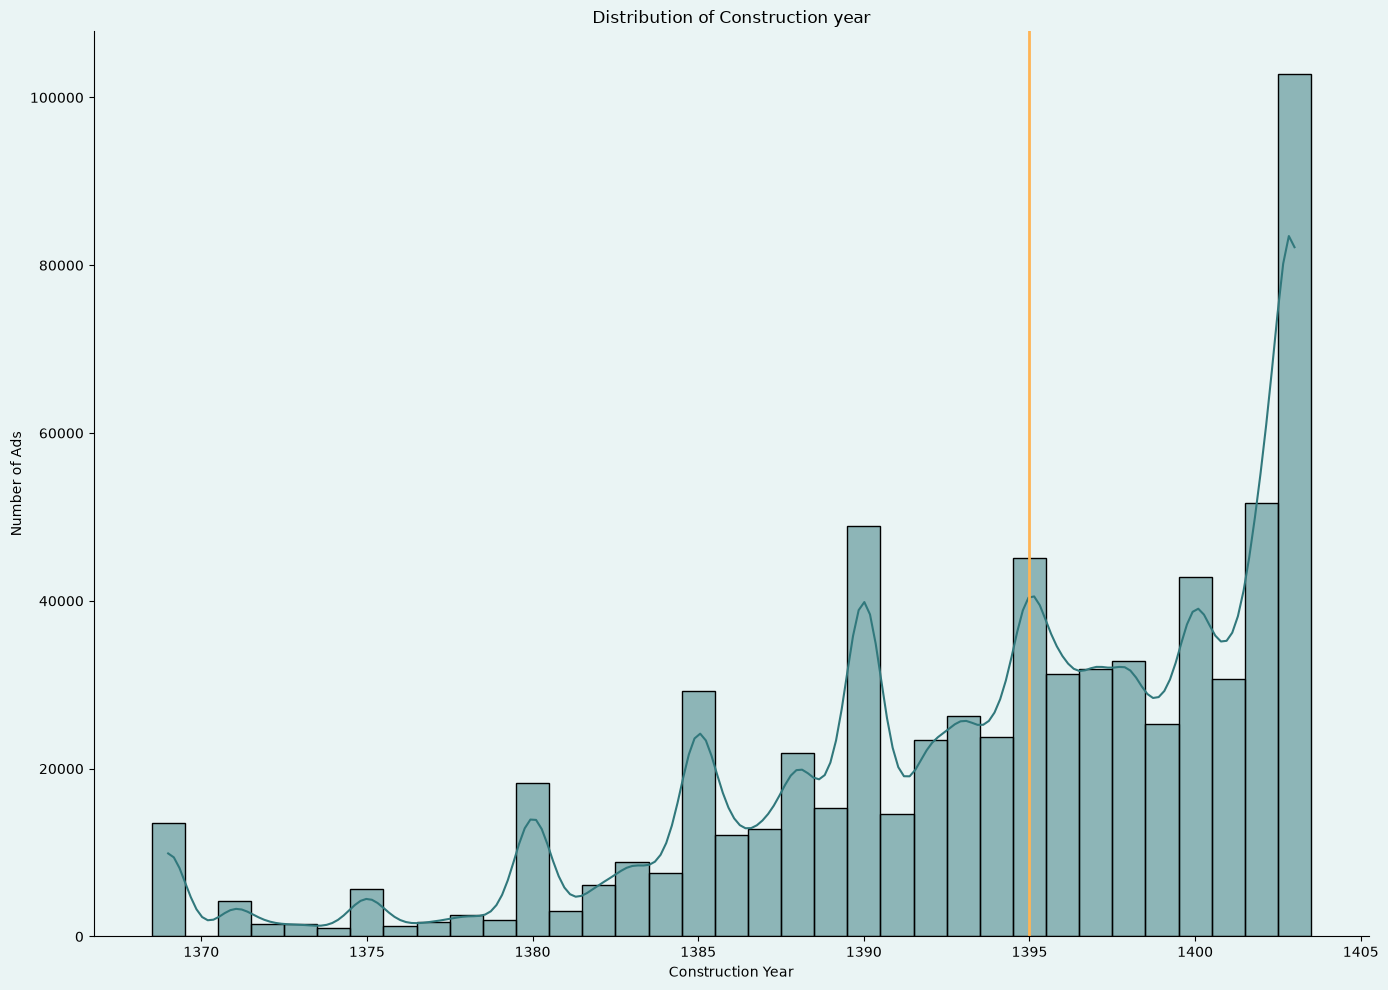

In [38]:
fig1, ax1 = plt.subplots(figsize=(14, 10))

sns.histplot(data=df_property, x='construction_year_numeric', bins=bins, kde=True, ax=ax1, color="#31787c")

ax1.axvline(df_property['construction_year_numeric'].median(), color='#ffb454', linewidth=2, label='Median')

ax1.set_title('Distribution of Construction year')
ax1.set_xlabel('Construction Year')
ax1.set_ylabel('Number of Ads')
ax1.spines.right.set_visible(False)
ax1.spines.top.set_visible(False)
ax1.set_facecolor(color='#EAF4f4')
fig1.set_facecolor('#EAF4f4')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

با رسم هیستوگرام سال ساخت، توزیع آگهی‌ها در سال‌های مختلف بررسی شد. در توزیع کل داده‌ها، فراوانی آگهی‌های مربوط به سال‌های ساخت جدیدتر بیشتر است و بیشترین تعداد آگهی‌ها در سال‌های انتهایی بازه، به‌ویژه سال ۱۴۰۳، مشاهده می‌شود.
اما بخاطر تعدا بالای ديتا های miss شده در ستون سال ساخت اول تصميم داشتم که با استفاده از ستون title و description داده های miss شده رو از روی توضيحات در صورت موجود بودن استخراج کنم که ما بين کار متوجه شدم که اکثر missing value ها اصلا به اگهي های فروش ملک مسکونی مربوط نميشوند و بيشتر در دسته های مشارک املاک يا اجاره های​ موقت بودن برای همين تصميم گرفتم که داده رو محدود بکنم به اگهی های مربوط به آپارتمان و خانه و ويلا در حالت فروش يا اجاره.

شکل کلی توزیع تغییر محسوسی نکرد و الگوی مشابهی مشاهده شد. این موضوع با توجه به اینکه این دسته‌ها بخش بزرگی از داده‌های اولیه را تشکیل می‌دهند قابل انتظار است.



</div>

In [ ]:
### bi zahmat in ghesmat azmone farzamo hatman check kon XD 

### آزمون فرض

<div dir="rtl" align="right">

برای بررسی این فرض که خانه‌های قدیمی‌ساخت مساحت بیشتری نسبت به خانه‌های جدیدساخت دارند، متغیرهای سال ساخت و مساحت زیربنا مورد استفاده قرار گرفتند.

خانه‌های ساخته‌شده قبل از سال ۱۳۹۶ به‌عنوان خانه‌های قدیمی‌ساخت و خانه‌های ساخته‌شده از سال ۱۳۹۶ به بعد به‌عنوان خانه‌های جدیدساخت در نظر گرفته شدند.

در این تحلیل، داده‌های دارای مقدار گمشده در سال ساخت یا متراژ ساختمان حذف شدند.

</div>

In [39]:
df_property['building_size'].isnull().sum()

np.int64(44)

In [40]:
test_df = df_property[['construction_year_numeric', 'building_size']].copy()

test_df.isna().sum()

construction_year_numeric    44
building_size                44
dtype: int64

In [41]:
test_df.shape

(701696, 2)

In [42]:
test_df = test_df.dropna(subset=['construction_year_numeric', 'building_size'])

test_df.shape

(701651, 2)

<div dir="rtl" align="right">

فرض صفر:

H0: mu old <= mu new

فرض مقابل:

H1: mu old > mu new

سطح معناداری آزمون برابر با ۰٫۰۵ در نظر گرفته شد.

</div>

In [43]:
old_houses = test_df[test_df['construction_year_numeric'] < 1396]
new_houses = test_df[test_df['construction_year_numeric'] >= 1396]

In [44]:
old_houses['building_size'].describe()

count    3.524920e+05
mean     1.149120e+03
std      6.881256e+04
min      1.000000e+00
25%      7.000000e+01
50%      8.800000e+01
75%      1.200000e+02
max      1.000000e+07
Name: building_size, dtype: float64

In [45]:
new_houses['building_size'].describe()

count    3.491590e+05
mean     1.500105e+03
std      7.662239e+04
min      1.000000e+00
25%      8.500000e+01
50%      1.080000e+02
75%      1.450000e+02
max      1.000000e+07
Name: building_size, dtype: float64

### بررسی و حذف مقادیر پرت


<div dir="rtl" align="right">

از آنجا که متراژ ساختمان دارای مقادیر پرت بسیار بزرگ بود (10 000 000 و 1111111و 99999 و ...)، برای کنترل اثر این مقادیر بر تحلیل، مقادیر پرت با استفاده از روش IQR شناسایی شدند.

حد پایین و بالای مقادیر قابل قبول برای هر یک از دو گروه به‌صورت جداگانه محاسبه شد و مقادیر خارج از این محدوده‌ها از تحلیل آزمون فرض حذف شدند.

</div>

In [46]:
Q1_old = old_houses['building_size'].quantile(0.25)
Q3_old = old_houses['building_size'].quantile(0.75)

IQR_old = Q3_old - Q1_old

lower_old = Q1_old - 1.5 * IQR_old
upper_old = Q3_old + 1.5 * IQR_old

In [47]:
Q1_new = new_houses['building_size'].quantile(0.25)
Q3_new = new_houses['building_size'].quantile(0.75)

IQR_new = Q3_new - Q1_new

lower_new = Q1_new - 1.5 * IQR_new
upper_new = Q3_new + 1.5 * IQR_new

In [48]:
print('Old houses:')
print('Lower:', lower_old)
print('Upper:', upper_old)

print('\nNew houses:')
print('Lower:', lower_new)
print('Upper:', upper_new)

Old houses:
Lower: -5.0
Upper: 195.0

New houses:
Lower: -5.0
Upper: 235.0


In [49]:
old_houses_clean = old_houses[(old_houses['building_size'] >= lower_old) & (old_houses['building_size'] <= upper_old)]

new_houses_clean = new_houses[(new_houses['building_size'] >= lower_new) & (new_houses['building_size'] <= upper_new)]

print('Old houses:', len(old_houses_clean))
print('New houses:', len(new_houses_clean))

print('Old houses')
print(old_houses_clean['building_size'].describe())

print('\nNew houses')
print(new_houses_clean['building_size'].describe())

Old houses: 324870
New houses: 326622
Old houses
count    324870.000000
mean         91.007831
std          33.851908
min           1.000000
25%          66.000000
50%          85.000000
75%         110.000000
max         195.000000
Name: building_size, dtype: float64

New houses
count    326622.000000
mean        110.683585
std          40.699354
min           1.000000
25%          82.000000
50%         104.000000
75%         135.000000
max         235.000000
Name: building_size, dtype: float64


نتایج توصیفی نشان می‌دهد میانگین مساحت خانه‌های قدیمی‌ساخت حدود ۹۱٫۰۱ مترمربع و میانگین مساحت خانه‌های جدیدساخت حدود ۱۱۰٫۶۸ مترمربع است.

بنابراین، اختلاف مشاهده‌شده در نمونه برخلاف فرض مطرح‌شده در سؤال است و میانگین مساحت خانه‌های جدید بیشتر از خانه‌های قدیمی است.

### توزیع متراژ ساختمان

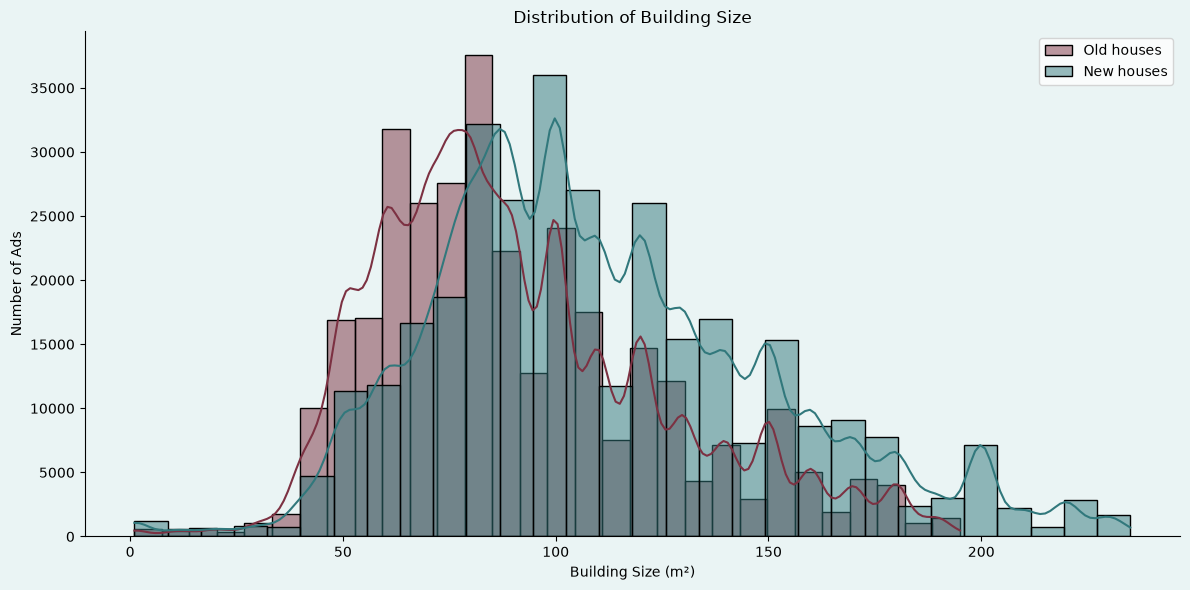

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(data=old_houses_clean, x='building_size', bins=30, kde=True, ax=ax, color='#7c3142', label='Old houses')
sns.histplot(data=new_houses_clean, x='building_size', bins=30, kde=True, ax=ax, color='#31787c', label='New houses')

ax.set_title('Distribution of Building Size')
ax.set_xlabel('Building Size (m²)')
ax.set_ylabel('Number of Ads')
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)
ax.set_facecolor('#EAF4f4')
fig.set_facecolor('#EAF4f4')
ax.legend()

plt.tight_layout()
plt.show()

In [51]:
old_mean = old_houses_clean['building_size'].mean()
new_mean = new_houses_clean['building_size'].mean()

print('Old mean:', old_mean)
print('New mean:', new_mean)

Old mean: 91.00783082463755
New mean: 110.68358530656232


<div dir="rtl" align="right">

### انتخاب آزمون آماری

متغیر `building_size` یک متغیر کمی پیوسته است و دو گروه مورد مقایسه مستقل از یکدیگر هستند.

با توجه به غیرنرمال بودن توزیع متراژ ساختمان، آزمون Mann–Whitney U به‌عنوان آزمون ناپارامتری برای مقایسه دو گروه مستقل استفاده شد.

همچنین آزمون t مستقل با روش Welch به‌صورت تکمیلی اجرا شد تا نتیجه حاصل از مقایسه دو گروه از طریق یک روش دیگر نیز بررسی شود.

</div>

In [53]:
u_stat, p_value = mannwhitneyu(
    old_houses_clean['building_size'],
    new_houses_clean['building_size'],
    alternative='greater'
)

print('U-statistic:', u_stat)
print('p-value:', p_value)

U-statistic: 37123786259.0
p-value: 1.0


<div dir="rtl" align="right">

### تحلیل نتایج آزمون فرض

نتیجه آزمون Mann–Whitney U 
p-value = 1.0

از آنجا که:
p-value = 1.0 > 0.05

فرض صفر رد نمی‌شود.

بنابراین، شواهد آماری کافی برای تأیید این فرض که مساحت خانه‌های قدیمی‌ساخت بیشتر از خانه‌های جدیدساخت است، وجود ندارد.

همچنین آمار توصیفی نشان می‌دهد میانگین مساحت خانه‌های قدیمی‌ساخت ۹۱٫۰۱ مترمربع و میانگین مساحت خانه‌های جدیدساخت ۱۱۰٫۶۸ مترمربع است. بنابراین در داده مورد بررسی، اختلاف مشاهده‌شده در جهت مخالف فرض مطرح‌شده در سؤال قرار دارد.

</div>

In [52]:
t_stat, p_value = stats.ttest_ind(
    old_houses_clean['building_size'],
    new_houses_clean['building_size'],
    equal_var=False,
    alternative='greater'
)

print('t-statistic:', t_stat)
print('p-value:', p_value)

t-statistic: -212.1834727945425
p-value: 1.0


<div dir="rtl" align="right">

### نتیجه‌گیری

بر اساس نتایج آزمون آماری و آمار توصیفی، شواهد کافی برای تأیید این فرض که خانه‌های قدیمی‌ساخت مساحت بیشتری نسبت به خانه‌های جدیدساخت دارند، مشاهده نشد.

در داده مورد بررسی، میانگین مساحت خانه‌های قدیمی‌ساخت ۹۱٫۰۱ مترمربع و میانگین مساحت خانه‌های جدیدساخت ۱۱۰٫۶۸ مترمربع بود. بنابراین، در این مجموعه داده، خانه‌های جدیدساخت به‌طور متوسط مساحت بیشتری داشتند.

نتایج آزمون Mann–Whitney و آزمون t مستقل هر دو يک جواب رو دادن .

</div>